In [1]:
import os
import cv2
import joblib
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

from pathlib import Path
from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

In [2]:
def analyze_caltech_dataset(dataset_path):
    d_path = Path(dataset_path)
    results = {"class_name": [], "image_count": []}
    for class_folder in d_path.iterdir():
        if class_folder.is_dir():
            valid_images = list(class_folder.glob("*.*"))
            results["class_name"].append(class_folder.name)
            results["image_count"].append(len(valid_images))
    return pd.DataFrame(results)

In [3]:
df_EDA = analyze_caltech_dataset("caltech101")
df_EDA

,class_name,image_count
0,accordion,55
1,airplanes,800
2,anchor,42
3,ant,42
4,barrel,47
...,...,...
96,wheelchair,59
97,wild_cat,34
98,windsor_chair,56
99,wrench,39


In [4]:
df_EDA.describe()

,image_count
count,101.000000
mean,80.811881
std,118.978377
min,0.000000
25%,42.000000
50%,56.000000
75%,76.000000
max,800.000000


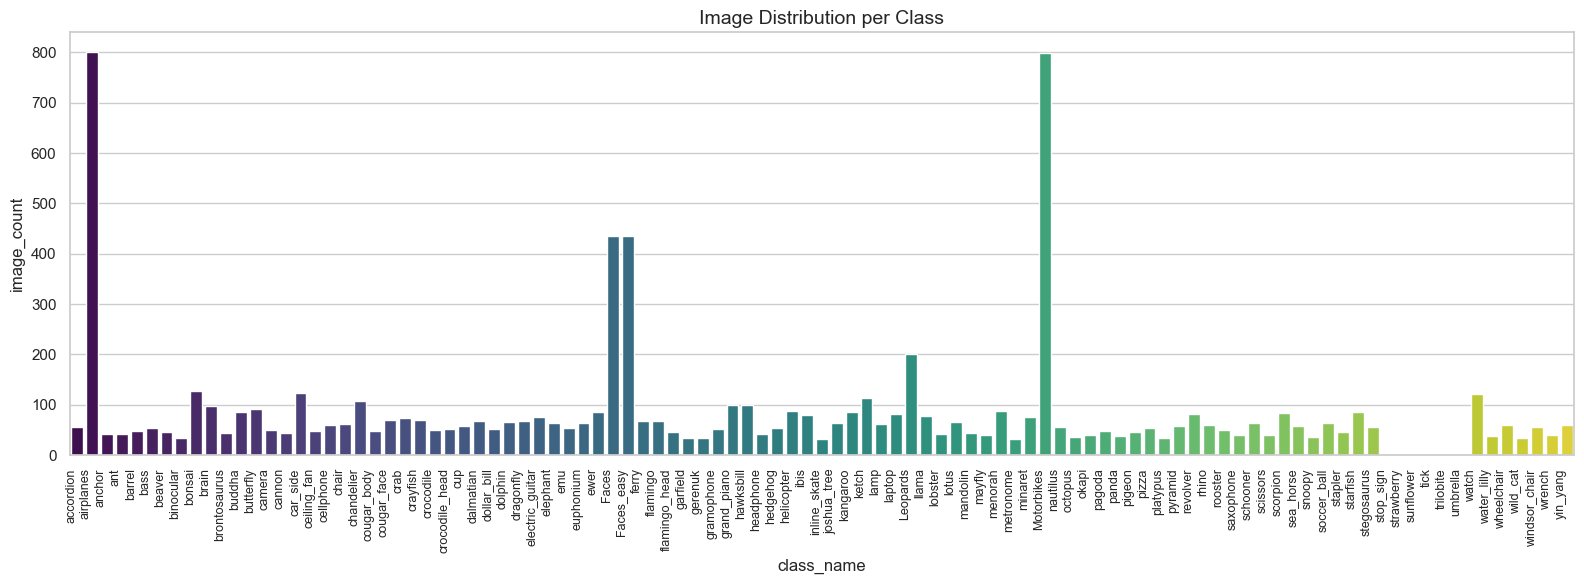

In [5]:
plt.figure(figsize=(16, 6))
sns.barplot(data=df_EDA, x="class_name", y="image_count", hue="class_name", palette="viridis", legend=False)
plt.xticks(rotation=90, ha="right", fontsize=9)
plt.title("Image Distribution per Class", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
print(f"Max image_count : {df_EDA[df_EDA['image_count'] == df_EDA['image_count'].max()].values}")

Max image_count : [['airplanes' 800]]


In [7]:
print(f"Min image_count : {df_EDA[df_EDA['image_count'] == df_EDA['image_count'].min()].values}")

Min image_count : [['stop_sign' 0]
 ['strawberry' 0]
 ['sunflower' 0]
 ['tick' 0]
 ['trilobite' 0]
 ['umbrella' 0]]


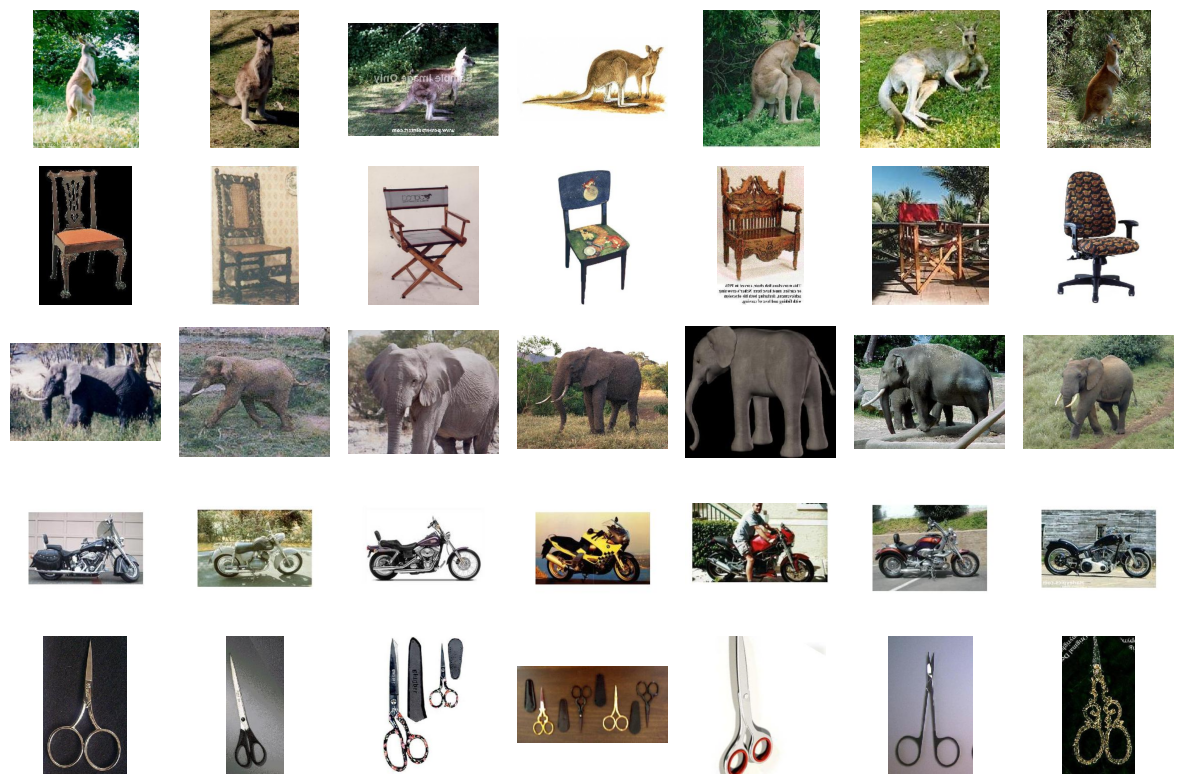

In [8]:
path = "caltech101"
classes = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
selected_classes = random.sample(classes, 5)
fig, axes = plt.subplots(5, 7, figsize=(12, 8))
for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(path, class_name)
    images = os.listdir(class_path)
    selected_images = random.sample(images, min(7, len(images)))
    for j, image_name in enumerate(selected_images):
        image_path = os.path.join(class_path, image_name)
        img = cv2.imread(image_path)
        if img is not None:
            axes[i, j].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if j == 0:
            axes[i, j].set_ylabel(class_name, fontsize=12)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()

In [9]:
dimensions = []
for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)
    if not os.path.isdir(class_path): continue
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        img = cv2.imread(image_path)
        if img is not None:
            h, w = img.shape[:2]
            dimensions.append((class_name, image_name, w, h))
df_dimn = pd.DataFrame(dimensions, columns=["class", "image", "width", "height"])
df_dimn

,class,image,width,height
0,accordion,image_0001.jpg,260,300
1,accordion,image_0002.jpg,232,300
2,accordion,image_0003.jpg,300,282
3,accordion,image_0004.jpg,300,199
4,accordion,image_0005.jpg,223,300
...,...,...,...,...
8157,yin_yang,image_0056.jpg,300,287
8158,yin_yang,image_0057.jpg,261,300
8159,yin_yang,image_0058.jpg,300,201
8160,yin_yang,image_0059.jpg,300,284


In [10]:
df_dimn.describe()

,width,height
count,8162.000000,8162.000000
mean,299.233889,237.987748
std,71.513557,64.442488
min,80.000000,92.000000
25%,262.000000,182.000000
50%,300.000000,235.500000
75%,300.000000,300.000000
max,708.000000,494.000000


In [11]:
df_dimn["width"].value_counts().head()

width
300    3701
261     514
192     183
225      87
262      79
Name: count, dtype: int64

In [12]:
df_dimn["height"].value_counts().head()

height
300    1961
225     283
197     194
128     174
200      77
Name: count, dtype: int64

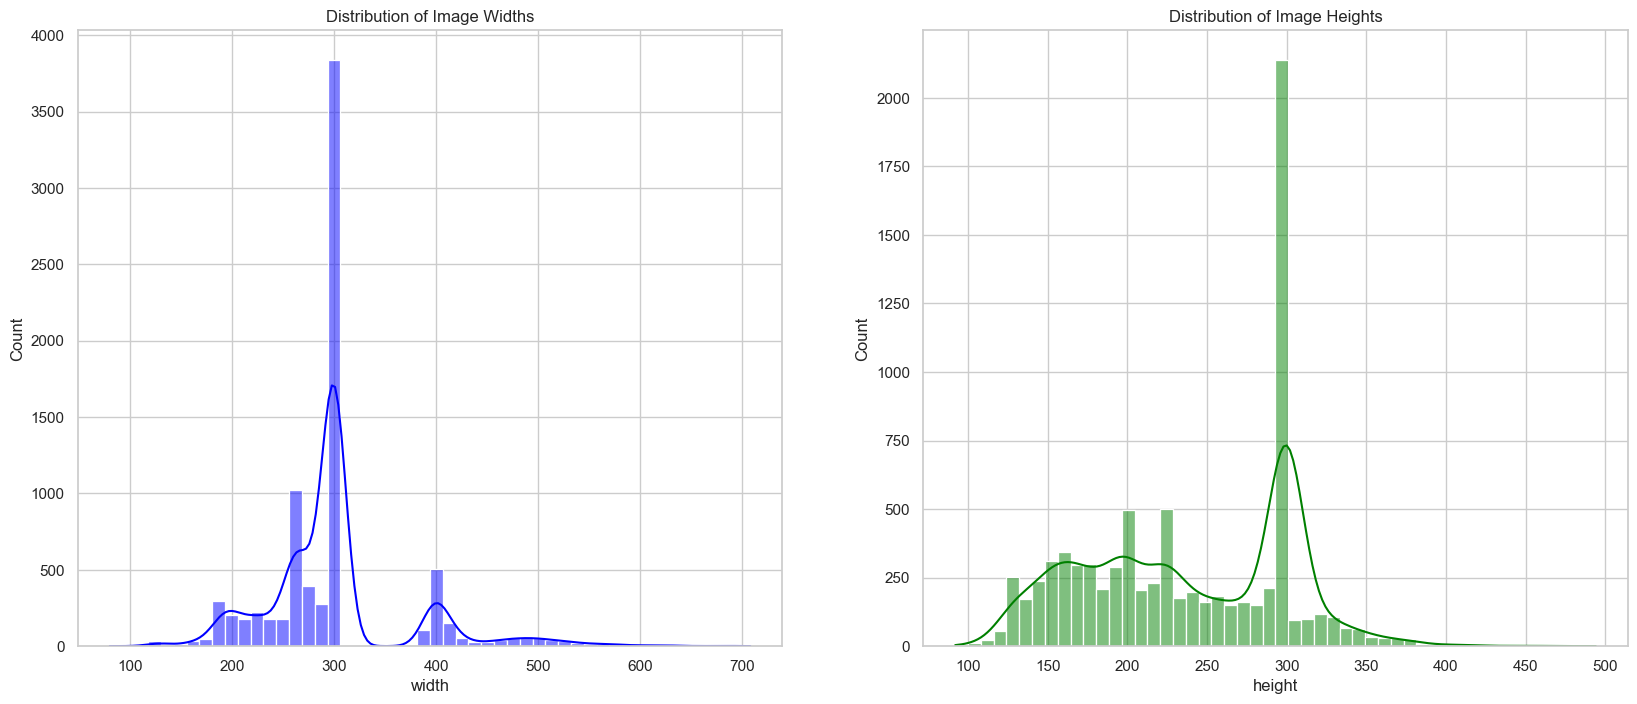

In [13]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
sns.histplot(df_dimn["width"], bins=50, kde=True, color="blue")
plt.title("Distribution of Image Widths")
plt.subplot(1, 2, 2)
sns.histplot(df_dimn["height"], bins=50, kde=True, color="green")
plt.title("Distribution of Image Heights")
plt.show()

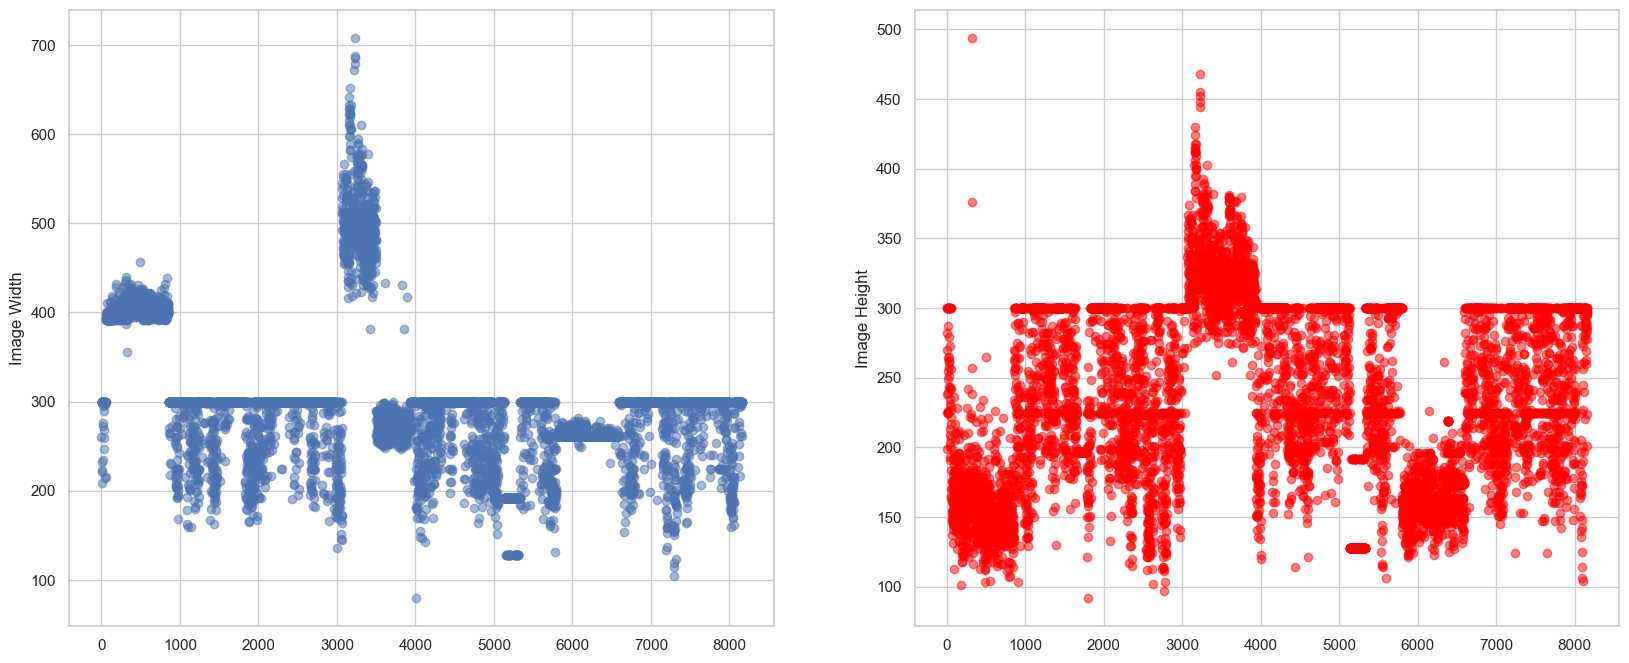

In [14]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.scatter(df_dimn.index, df_dimn["width"], alpha=0.5)
plt.ylabel("Image Width")
plt.subplot(1, 2, 2)
plt.scatter(df_dimn.index, df_dimn["height"], alpha=0.5, color="red")
plt.ylabel("Image Height")
plt.show()

In [15]:
channels = []
for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)
    if not os.path.isdir(class_path): continue
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        img = cv2.imread(image_path)
        if img is not None:
            channels.append((class_name, image_name, img.shape[2] if len(img.shape) == 3 else 1))
df_chnl = pd.DataFrame(channels, columns=["class", "image", "channel"])
df_chnl

,class,image,channel
0,accordion,image_0001.jpg,3
1,accordion,image_0002.jpg,3
2,accordion,image_0003.jpg,3
3,accordion,image_0004.jpg,3
4,accordion,image_0005.jpg,3
...,...,...,...
8157,yin_yang,image_0056.jpg,3
8158,yin_yang,image_0057.jpg,3
8159,yin_yang,image_0058.jpg,3
8160,yin_yang,image_0059.jpg,3


In [16]:
df_chnl["channel"].value_counts()

channel
3    8162
Name: count, dtype: int64

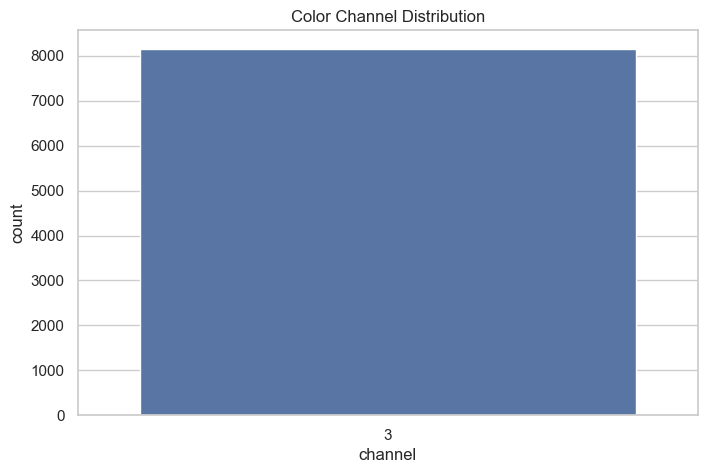

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_chnl, x="channel")
plt.title("Color Channel Distribution")
plt.show()

In [18]:
df_dimn["ratio"] = df_dimn["width"] / df_dimn["height"]
df_dimn

,class,image,width,height,ratio
0,accordion,image_0001.jpg,260,300,0.866667
1,accordion,image_0002.jpg,232,300,0.773333
2,accordion,image_0003.jpg,300,282,1.063830
3,accordion,image_0004.jpg,300,199,1.507538
4,accordion,image_0005.jpg,223,300,0.743333
...,...,...,...,...,...
8157,yin_yang,image_0056.jpg,300,287,1.045296
8158,yin_yang,image_0057.jpg,261,300,0.870000
8159,yin_yang,image_0058.jpg,300,201,1.492537
8160,yin_yang,image_0059.jpg,300,284,1.056338


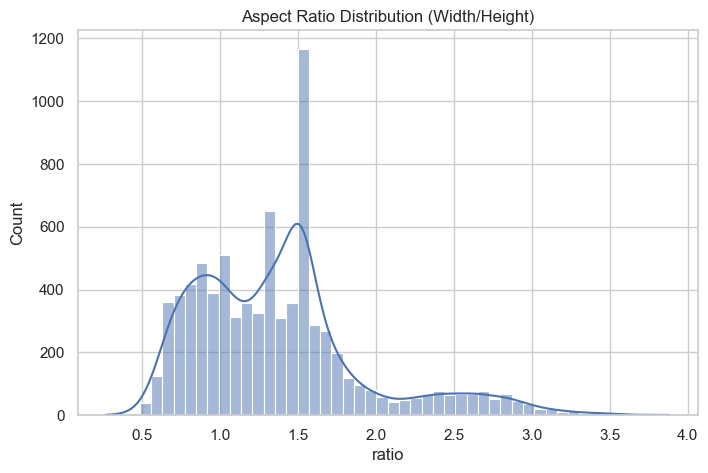

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df_dimn["ratio"], bins=50, kde=True)
plt.title("Aspect Ratio Distribution (Width/Height)")
plt.show()

In [20]:
data_records = []
for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)
    if not os.path.isdir(class_path): continue
    for image_name in os.listdir(class_path):
        data_records.append({"label": class_name, "file_path": os.path.join(class_path, image_name)})
df = pd.DataFrame(data_records)
df

,label,file_path
0,accordion,caltech101\accordion\image_0001.jpg
1,accordion,caltech101\accordion\image_0002.jpg
2,accordion,caltech101\accordion\image_0003.jpg
3,accordion,caltech101\accordion\image_0004.jpg
4,accordion,caltech101\accordion\image_0005.jpg
...,...,...
8157,yin_yang,caltech101\yin_yang\image_0056.jpg
8158,yin_yang,caltech101\yin_yang\image_0057.jpg
8159,yin_yang,caltech101\yin_yang\image_0058.jpg
8160,yin_yang,caltech101\yin_yang\image_0059.jpg


In [21]:
encoder = LabelEncoder()
df["encoded_label"] = encoder.fit_transform(df["label"])
df["encoded_label"]

0        4
1        4
2        4
3        4
4        4
        ..
8157    94
8158    94
8159    94
8160    94
8161    94
Name: encoded_label, Length: 8162, dtype: int64

In [22]:
classes_label = encoder.classes_
classes_label

array(['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion',
       'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver',
       'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha',
       'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan',
       'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face',
       'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup',
       'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly',
       'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry',
       'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone',
       'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter',
       'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp',
       'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly',
       'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi',
       'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid',
       'revolver', 'rhino', 'r

In [23]:
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    img = cv2.imread(image_path)
    if img is None: 
        return np.zeros((target_size[0], target_size[1], 3), dtype=np.uint8)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img_rgb, dsize=target_size, interpolation=cv2.INTER_AREA)

In [24]:
print("Processing images... (Optimized for Memory)")
X_list = [load_and_preprocess_image(p) for p in df["file_path"]]

Processing images... (Optimized for Memory)


In [25]:
X = np.array(X_list)
y = df["encoded_label"].values.astype("int16")

del X_list
del df
gc.collect() 

print("Matrix created and RAM cleared!")

Matrix created and RAM cleared!


In [26]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

del X
del y
gc.collect()

print("Data splitted successfully!")

Data splitted successfully!


In [27]:
values, counts = np.unique(y_train, return_counts=True)
print(f"min: {counts.min()}, max: {counts.max()}, median: {np.median(counts)}")

min: 25, max: 640, median: 46.0


In [28]:
target_count = int(np.percentile(counts, 75))
print(f"target count: {target_count}")

target count: 63


In [29]:
class_count = dict(zip(values, counts))
deficits = {cls: max(0, target_count - cnt) for cls, cnt in class_count.items()}

In [30]:
def augment_image(image):
    h, w = image.shape[:2]
    angle = np.random.uniform(-15, 15)
    matrix = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    img_aug = cv2.warpAffine(image, matrix, (w, h), borderMode=cv2.BORDER_REFLECT_101)
    if np.random.rand() < 0.5:
        img_aug = cv2.flip(img_aug, 1)
    return cv2.convertScaleAbs(img_aug, alpha=np.random.uniform(0.8, 1.2), beta=np.random.uniform(-20, 20))

In [31]:
x_aug_list = []
y_aug_list = []
for cls, deficit in deficits.items():
    if deficit > 0:
        indices = np.where(y_train == cls)[0]
        for _ in range(deficit):
            idx = np.random.choice(indices)
            x_aug_list.append(augment_image(x_train[idx]))
            y_aug_list.append(cls)
x_aug = np.array(x_aug_list) if x_aug_list else np.empty((0, *x_train.shape[1:]))
y_aug = np.array(y_aug_list) if y_aug_list else np.empty(0)

In [32]:
if len(x_aug) > 0:
    x_train_balanced = np.concatenate([x_train, x_aug], axis=0)
    y_train_balanced = np.concatenate([y_train, y_aug], axis=0)
else:
    x_train_balanced, y_train_balanced = x_train, y_train
print(f"Before: {x_train.shape}, After: {x_train_balanced.shape}")

Before: (6529, 128, 128, 3), After: (8067, 128, 128, 3)


In [33]:
values_bal, counts_bal = np.unique(y_train_balanced, return_counts=True)
print(f"Min: {counts_bal.min()}, Max: {counts_bal.max()}, Median: {np.median(counts_bal)}")

Min: 63, Max: 640, Median: 63.0


In [34]:
def extract_hog(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm="L2-Hys")

In [35]:
X_train_hog = np.array([extract_hog(img) for img in x_train_balanced])
X_test_hog = np.array([extract_hog(img) for img in x_test])
print(f"Train HOG shape: {X_train_hog.shape}")
print(f"Test HOG shape: {X_test_hog.shape}")

Train HOG shape: (8067, 8100)
Test HOG shape: (1633, 8100)


In [36]:
raw_pixel_dim = 128 * 128 * 3
hog_dim = X_train_hog.shape[1]
print(f"Raw flattened dim: {raw_pixel_dim}, HOG dim: {hog_dim}, reduction: {raw_pixel_dim/hog_dim:.1f}x")

Raw flattened dim: 49152, HOG dim: 8100, reduction: 6.1x


In [37]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("svm", SVC(class_weight="balanced"))
])

param_grid = {
    "pca__n_components": [100], 
    "svm__kernel": ["linear", "rbf"], 
    "svm__C": [1],
    "svm__gamma": ["scale"]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    scoring="f1_macro",
    cv=2,         
    n_jobs=-1,
    verbose=2,
    random_state=42,
    n_iter=2       
)

print("Training a lightweight model to save time...")
random_search.fit(X_train_hog, y_train_balanced)

Training a lightweight model to save time...
Fitting 2 folds for each of 2 candidates, totalling 4 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'pca__n_components': [100], 'svm__C': [1], 'svm__gamma': ['scale'], 'svm__kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_inde

In [38]:
print(f"Best params: {random_search.best_params_}")
print(f"Best CV F1-macro: {random_search.best_score_}")

Best params: {'svm__kernel': 'rbf', 'svm__gamma': 'scale', 'svm__C': 1, 'pca__n_components': 100}
Best CV F1-macro: 0.5435547600937228


In [39]:
joblib.dump(random_search.best_estimator_, "svm_model_kasra.pkl")
loaded_model = joblib.load("svm_model_kasra.pkl")

In [40]:
y_pred = loaded_model.predict(X_test_hog)

In [41]:
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Test F1-macro: {f1_score(y_test, y_pred, average='macro')}")
print(f"Test F1-weighted: {f1_score(y_test, y_pred, average='weighted')}")

Test Accuracy: 0.6631965707287202
Test F1-macro: 0.5186812952280386
Test F1-weighted: 0.665502881265331


In [42]:
report_dict = classification_report(y_test, y_pred, target_names=classes_label, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.drop(["accuracy", "macro avg", "weighted avg"])
report_df = report_df.sort_values("f1-score", ascending=False)

In [43]:
report_df.head(15)

,precision,recall,f1-score,support
pagoda,1.000000,1.000000,1.000000,9.0
Faces_easy,1.000000,0.988506,0.994220,87.0
airplanes,0.993548,0.962500,0.977778,160.0
Motorbikes,0.993506,0.956250,0.974522,160.0
minaret,1.000000,0.933333,0.965517,15.0
car_side,0.925926,1.000000,0.961538,25.0
grand_piano,1.000000,0.900000,0.947368,20.0
Faces,0.940476,0.908046,0.923977,87.0
accordion,0.846154,1.000000,0.916667,11.0
laptop,0.882353,0.937500,0.909091,16.0


In [44]:
report_df.tail(15)

,precision,recall,f1-score,support
panda,1.000000,0.125000,0.222222,8.0
beaver,0.222222,0.222222,0.222222,9.0
scorpion,0.272727,0.176471,0.214286,17.0
flamingo,0.200000,0.230769,0.214286,13.0
crocodile,0.133333,0.400000,0.200000,10.0
gerenuk,0.115385,0.428571,0.181818,7.0
bass,0.166667,0.181818,0.173913,11.0
cannon,0.142857,0.222222,0.173913,9.0
brontosaurus,0.250000,0.111111,0.153846,9.0
crocodile_head,0.117647,0.200000,0.148148,10.0


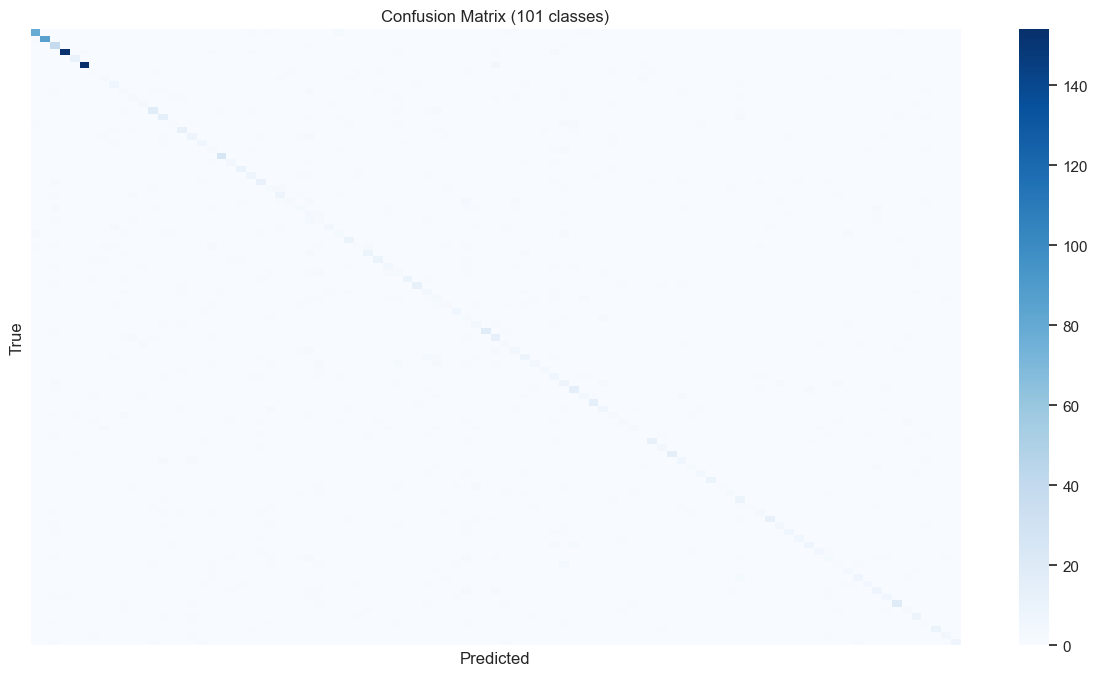

In [45]:
plt.figure(figsize=(15, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap="Blues", xticklabels=False, yticklabels=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (101 classes)")
plt.show()

In [46]:
train_counts_before_balance = dict(zip(*np.unique(y_train, return_counts=True)))
label_to_count = {classes_label[i]: train_counts_before_balance.get(i, 0) for i in range(len(classes_label))}
report_df["original_train_count"] = report_df.index.map(label_to_count)

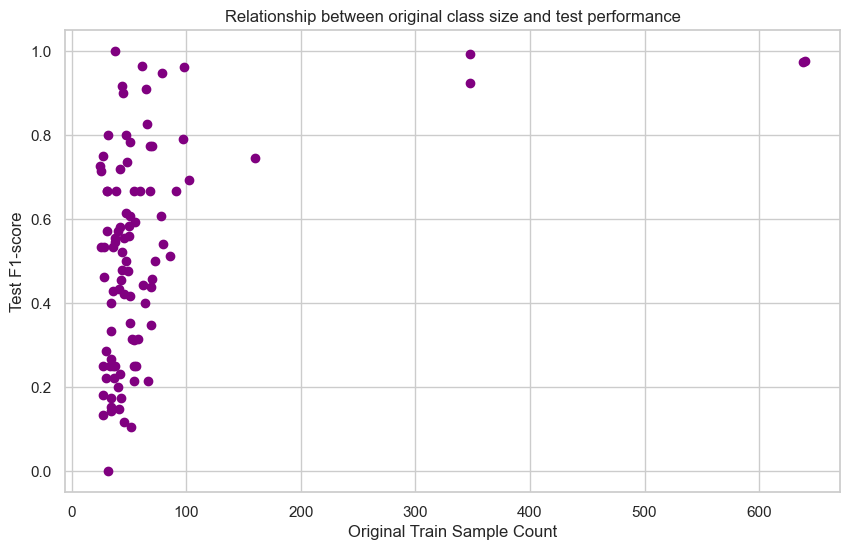

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(report_df["original_train_count"], report_df["f1-score"], color="purple")
plt.xlabel("Original Train Sample Count")
plt.ylabel("Test F1-score")
plt.title("Relationship between original class size and test performance")
plt.show()

In [48]:
cm = confusion_matrix(y_test, y_pred)
np.fill_diagonal(cm, 0)
confusion_pairs = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            confusion_pairs.append((classes_label[i], classes_label[j], cm[i, j]))
confusion_pairs_df = pd.DataFrame(confusion_pairs, columns=["True", "Predicted", "Count"])
confusion_pairs_df.sort_values("Count", ascending=False).head(15)

,True,Predicted,Count
15,airplanes,hawksbill,5
124,crab,gerenuk,4
144,crocodile_head,crocodile,4
253,helicopter,ferry,4
409,sea_horse,kangaroo,4
103,chandelier,Leopards,3
2,Faces,dalmatian,3
389,schooner,ketch,3
260,ibis,emu,3
282,ketch,schooner,3
